In [132]:
import time
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

In [101]:
mpl.rcParams.update({
    'font.family': 'Helvetica',
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor': '#f8f9fa',
    'axes.edgecolor': '#ecf0f1',
    'axes.linewidth': 1.5,
    'axes.grid': True,
    'axes.axisbelow': True,
    'grid.color': '#ecf0f1',
    'grid.alpha': 0.7,
    'text.color': '#2c3e50',
    'axes.labelcolor': '#2c3e50',
    'xtick.color': '#2c3e50',
    'ytick.color': '#2c3e50',
    'font.size': 10,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.color': '#e74c3c',
    'lines.linewidth': 3,
    'lines.markersize': 8
})

In [122]:
def fib_fast(n, f0 = 0, f1 = 1) -> int:
    """
    iteratively solves a recurrence that performs matrix exponentiation
    """
    a, b = 0, 1
    for bit in f"{n:b}":
        a, b = (a + 2 * b) * a, a * a + b * b
        if bit == "1":
            a, b = a + b, a
    return a * f1 + b * f0

def time_function(func, n):
    """time our algorithms"""
    start = time.time()
    result = func(n)
    end = time.time()
    return result, end - start

# 3.1.A More Recursion, Call Stack Analysis

In this lesson, we delve deeper into recursion and explore possible pitfalls we can encounter. While recursion, once mastered, lends itself to very elegant and easy to understand programs, recursive calls aren't free computational resources. 

### Fibonacci Sequence.

The Fibonacci sequence is defined by the following recurrence
\begin{align*}
F_0 = 0, F_1 = 1. \newline
\forall n > 1. \qquad F_n = F_{n - 1} + F_{n - 2}
\end{align*}

In [33]:
def fib(n):
    # required: fib(n) must return the n-th
    # fibonacci number as defined above
    # pass
    # solution:
    if n < 2:
        return n
    else:
        return fib(n - 1) + fib(n - 2)

In [23]:
print("first 10 Fibonacci numbers:")
for i in range(10):
    print(f"  F_{i} = {fib(i)}")

first 10 Fibonacci numbers:
  F_0 = 0
  F_1 = 1
  F_2 = 1
  F_3 = 2
  F_4 = 3
  F_5 = 5
  F_6 = 8
  F_7 = 13
  F_8 = 21
  F_9 = 34


What happens if we try to compute extremely large elements? For comparison, we have also included a fast (but advanced) algorithm for computing the elements of the sequence.

In [123]:
test_values = list(range(20, 40, 2))
times = []
times_fast = []

for n in test_values:
    _, elapsed = time_function(fib, n)
    _, elapsed_fast = time_function(fib_fast, n)
    times.append(elapsed)
    times_fast.append(elapsed_fast)
    print(".", end="")

..........

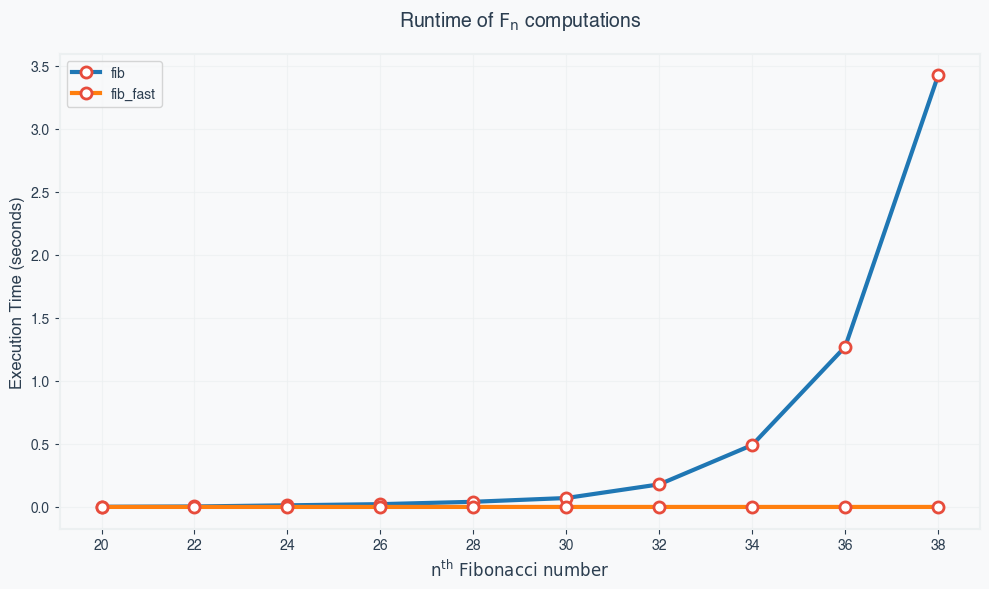


🚨 Notice: Each increase of 2 in n roughly doubles the execution time!


In [133]:
plt.figure(figsize=(10, 6))
plt.plot(test_values, times, 'o-', markerfacecolor='white', 
         markeredgecolor='#e74c3c', markeredgewidth=2)
plt.plot(test_values, times_fast, 'o-', markerfacecolor='white', 
         markeredgecolor='#e74c3c', markeredgewidth=2)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel(r'$\mathrm{n}^{\text{th}} \text{ Fibonacci number}$')
plt.ylabel('Execution Time (seconds)')
plt.title(r'Runtime of $\mathrm{F_n}$ computations', pad=20, fontweight='600')
# plt.yscale('log')
plt.legend(["fib", "fib_fast"])
plt.tight_layout()
plt.show()

print(f"\n🚨 Notice: Each increase of 2 in n roughly doubles the execution time!")

### Analyzing Recursive Calls & The Call Stack.

## Coding Exercises

### 1. Faster Fibonacci.
Implement an iterative algorithm to compute the $n^{\text{th}}$ Fibonacci number.

In [58]:
def fib_iter(n):
    pass
    # solution: 
    # a, b = 1, 0
    # for _ in range(n):
    #     a, b = b, a + b
    # return b

In [ ]:
print("first 10 Fibonacci numbers:")
for i in range(10):
    print(f"  fib({i}) = {fib(i)}, fib_iter({i}) = {fib_iter(i)}")

print(f"F_100 = {fib_iter(100)}")

### 2. Collatz Conjecture.

Define the function $f: \mathbb{N} \to \mathbb{N}$ by
\begin{align*}
f(n) = \begin{cases}
n/2 &\text{if $n$ even,}\\
3n + 1 &\text{otherwise.}
\end{cases}
\end{align*}

A longstanding open conjecture is that for any positive $n \in \mathbb{N}$, by successively applying $f$ to $n$, we will obtain $1$.
\begin{align*}
f^{(i)}(n) = \underbrace{f(f(\dots(f(}_{i \text{ many times}}n))\dots )) = 1.
\end{align*}

Write a recursive implementation of $f$ that prints out the values of the sequence and returns the number of steps.

In [141]:
def collatz(n):
    """Print out the Collatz sequence starting at n, and return the
    number of elements until we reach 1 for the first time.

    >>> a = collatz(10)
    10
    5
    16
    8
    4
    2
    1
    >>> a
    7
    """
    pass
    # answer
    # print(n)
    # if n % 2 == 0:
    #     return 1 + collatz(n//2)
    # elif n != 1:
    #     return 1 + collatz(3*n+1)
    # else:
    #     return 1

a=collatz(10)
print(f"Reached 1 from 10 in {a} many steps.")

Reached 1 from 10 in None many steps.


### 3. Decomposing into a sum.
_This problem is from Addiscoder '24._

Given a value $n$, produce a list of all different ways to write $n$ as the sum of positive non-increasing terms
Example: For $n=4$,
The function should produce the list
```python
[[1, 1, 1, 1],
[2, 1, 1],
[2, 2],
[3, 1],
[4]]
```

In [175]:
def writing_as_sum(n):
    if n <= 0: return [[]]
    out = []
    for i in range(n, 0, -1):
        for l in writing_as_sum(n - i):
            l.append(i)
            out.append(l)
    return out

In [177]:
writing_as_sum(5)

[[5],
 [1, 4],
 [2, 3],
 [1, 1, 3],
 [3, 2],
 [1, 2, 2],
 [2, 1, 2],
 [1, 1, 1, 2],
 [4, 1],
 [1, 3, 1],
 [2, 2, 1],
 [1, 1, 2, 1],
 [3, 1, 1],
 [1, 2, 1, 1],
 [2, 1, 1, 1],
 [1, 1, 1, 1, 1]]

### 4. Fix It!